<a href="https://colab.research.google.com/github/yohperez/EjemplosMates/blob/main/matrix_life.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 MATRIX LIFE — Autómata Celular con Matrices NumPy

> **Juego de la Vida de Conway** implementado con operaciones puras sobre matrices 2D.

---

## ¿Qué es el Juego de la Vida?

El **Juego de la Vida** de John Conway (1970) es un **autómata celular** que evoluciona en una cuadrícula 2D. Cada célula puede estar **viva** (1) o **muerta** (0), y su estado en la siguiente generación depende de sus **8 vecinos**.

### Reglas de Conway (B3/S23)

| Estado actual | Vecinos vivos | Estado siguiente |
|:---:|:---:|:---:|
| 🟦 Viva | < 2 | 💀 Muere (soledad) |
| 🟦 Viva | 2 ó 3 | 🟦 Sobrevive |
| 🟦 Viva | > 3 | 💀 Muere (hacinamiento) |
| ⬛ Muerta | exactamente 3 | 🟦 Nace |

### Técnica matricial
Todo el cómputo se realiza con **álgebra de matrices NumPy** — sin bucles Python sobre las células individuales. La clave es `np.roll()` para desplazar la matriz en las 8 direcciones y sumar los vecinos en paralelo.


## 📦 1. Importaciones y configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.widgets import Button, Slider
from matplotlib import colors
import warnings
warnings.filterwarnings('ignore')

# Configuración inline para Jupyter
%matplotlib inline

print("✅ Librerías cargadas correctamente")
print(f"   NumPy    {np.__version__}")
print(f"   Matplotlib {plt.matplotlib.__version__}")

✅ Librerías cargadas correctamente
   NumPy    2.0.2
   Matplotlib 3.10.0


## ⚙️ 2. Parámetros globales

Aquí puedes ajustar el tamaño del mundo y la densidad inicial de células vivas.

In [2]:
# ── Parámetros del mundo ──
FILAS = 80       # número de filas de la matriz
COLS  = 120      # número de columnas de la matriz
DENSI = 0.28     # densidad inicial (fracción de células vivas)
FPS   = 12       # velocidad de animación (generaciones/segundo)

print(f"Mundo:    {FILAS} × {COLS} = {FILAS*COLS:,} células")
print(f"Densidad: {DENSI*100:.0f}% de células vivas al inicio")
print(f"FPS:      {FPS} generaciones/segundo")

Mundo:    80 × 120 = 9,600 células
Densidad: 28% de células vivas al inicio
FPS:      12 generaciones/segundo


## 🔢 3. Lógica de matrices — el corazón del autómata

### `crear_matriz_aleatoria`
Genera una matriz 2D binaria usando `np.random.rand` y una máscara booleana.

### `contar_vecinos`
Cuenta los 8 vecinos de cada célula desplazando la matriz con `np.roll()`.  
El mundo es **toroide**: el borde derecho conecta con el izquierdo, y el superior con el inferior.

```
  ↖  ↑  ↗
  ←  ·  →     ← 8 direcciones de np.roll()
  ↙  ↓  ↘
```

### `siguiente_generacion`
Aplica las reglas de Conway con **máscaras booleanas** sobre toda la matriz a la vez.

In [3]:
def crear_matriz_aleatoria(filas, cols, densidad=0.3):
    """Genera una matriz 2D binaria aleatoria."""
    return (np.random.rand(filas, cols) < densidad).astype(np.int8)


def contar_vecinos(matriz):
    """
    Cuenta los vecinos vivos de cada célula con np.roll().
    El mundo es toroide: los bordes se conectan entre sí.
    Sin ningún bucle Python — pura álgebra matricial.
    """
    M = matriz
    vecinos = (
        np.roll(np.roll(M, -1, 0), -1, 1) +  # ↖ arriba-izquierda
        np.roll(M, -1, 0)                    +  # ↑ arriba
        np.roll(np.roll(M, -1, 0),  1, 1)   +  # ↗ arriba-derecha
        np.roll(M,  1, 1)                    +  # ← izquierda
        np.roll(M, -1, 1)                    +  # → derecha
        np.roll(np.roll(M,  1, 0), -1, 1)   +  # ↙ abajo-izquierda
        np.roll(M,  1, 0)                    +  # ↓ abajo
        np.roll(np.roll(M,  1, 0),  1, 1)      # ↘ abajo-derecha
    )
    return vecinos


def siguiente_generacion(matriz, edad):
    """
    Aplica las reglas de Conway con operaciones matriciales puras.

    Retorna:
        nueva_matriz — estado siguiente (0 = muerta, 1 = viva)
        nueva_edad   — edad acumulada de cada célula (para colorear)
    """
    v = contar_vecinos(matriz)

    # Máscaras booleanas — se evalúan en paralelo sobre TODA la matriz
    sobrevive = (matriz == 1) & ((v == 2) | (v == 3))
    nace      = (matriz == 0) & (v == 3)

    nueva_matriz = (sobrevive | nace).astype(np.int8)

    # Las células que viven acumulan +1 de edad
    nueva_edad = np.where(nueva_matriz == 1, edad + 1, 0)
    nueva_edad = np.clip(nueva_edad, 0, 30)   # saturar en 30 para la paleta

    return nueva_matriz, nueva_edad


print("✅ Funciones de lógica matricial definidas")

✅ Funciones de lógica matricial definidas


## 🔬 4. Demo: evolución rápida en consola

Antes de visualizar, veamos la lógica en acción sobre una matriz pequeña.

In [4]:
# Demo con matriz pequeña para verificar la lógica
np.random.seed(42)
demo = crear_matriz_aleatoria(10, 15, densidad=0.35)
edad_demo = np.zeros_like(demo)

print("═" * 40)
print("GENERACIÓN 0 — Estado inicial")
print("═" * 40)
print(f"  Células vivas:  {demo.sum():>4}")
print(f"  Células muertas:{(demo == 0).sum():>4}")
print()

for g in range(1, 6):
    demo, edad_demo = siguiente_generacion(demo, edad_demo)
    print(f"  Gen {g:>2} → vivas: {demo.sum():>4}  |  edad máx: {edad_demo.max():>2}")

print()
print("✅ La lógica funciona correctamente")

════════════════════════════════════════
GENERACIÓN 0 — Estado inicial
════════════════════════════════════════
  Células vivas:    63
  Células muertas:  87

  Gen  1 → vivas:   53  |  edad máx:  1
  Gen  2 → vivas:   48  |  edad máx:  2
  Gen  3 → vivas:   40  |  edad máx:  3
  Gen  4 → vivas:   43  |  edad máx:  4
  Gen  5 → vivas:   46  |  edad máx:  5

✅ La lógica funciona correctamente


## 🛸 5. Patrones clásicos del Juego de la Vida

Estas figuras tienen comportamientos fascinantes y predecibles.

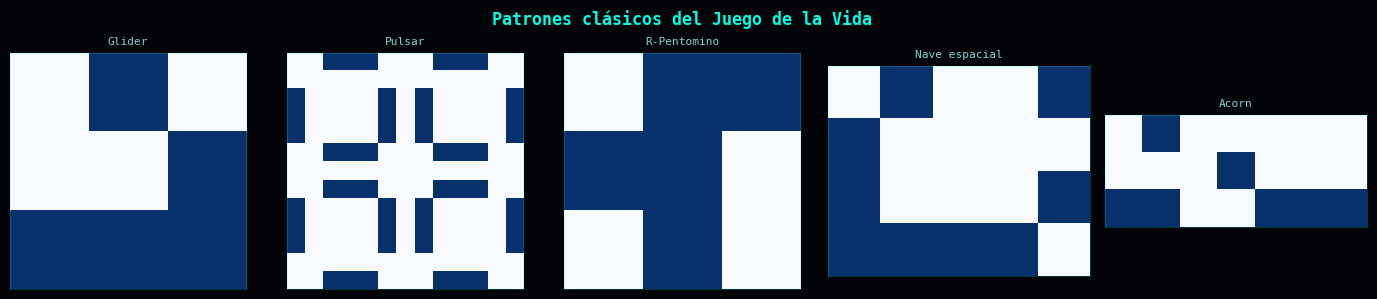

✅ Patrones definidos: ['Glider', 'Pulsar', 'R-Pentomino', 'Nave espacial', 'Acorn']


In [5]:
PATRONES = {
    "Glider": np.array([
        [0,1,0],
        [0,0,1],
        [1,1,1]
    ]),
    "Pulsar": np.array([
        [0,0,1,1,1,0,0,0,1,1,1,0,0],
        [0,0,0,0,0,0,0,0,0,0,0,0,0],
        [1,0,0,0,0,1,0,1,0,0,0,0,1],
        [1,0,0,0,0,1,0,1,0,0,0,0,1],
        [1,0,0,0,0,1,0,1,0,0,0,0,1],
        [0,0,1,1,1,0,0,0,1,1,1,0,0],
        [0,0,0,0,0,0,0,0,0,0,0,0,0],
        [0,0,1,1,1,0,0,0,1,1,1,0,0],
        [1,0,0,0,0,1,0,1,0,0,0,0,1],
        [1,0,0,0,0,1,0,1,0,0,0,0,1],
        [1,0,0,0,0,1,0,1,0,0,0,0,1],
        [0,0,0,0,0,0,0,0,0,0,0,0,0],
        [0,0,1,1,1,0,0,0,1,1,1,0,0],
    ]),
    "R-Pentomino": np.array([
        [0,1,1],
        [1,1,0],
        [0,1,0]
    ]),
    "Nave espacial": np.array([
        [0,1,0,0,1],
        [1,0,0,0,0],
        [1,0,0,0,1],
        [1,1,1,1,0]
    ]),
    "Acorn": np.array([
        [0,1,0,0,0,0,0],
        [0,0,0,1,0,0,0],
        [1,1,0,0,1,1,1]
    ]),
}

def insertar_patron(matriz, idx):
    """Coloca un patrón en el centro de la matriz."""
    patron = list(PATRONES.values())[idx % len(PATRONES)]
    pr, pc = patron.shape
    cr = FILAS // 2 - pr // 2
    cc = COLS  // 2 - pc // 2
    nueva = matriz.copy()
    nueva[cr:cr+pr, cc:cc+pc] = patron
    return nueva

# Mostrar los patrones
fig_p, axes = plt.subplots(1, 5, figsize=(14, 3), facecolor='#020408')
fig_p.suptitle('Patrones clásicos del Juego de la Vida',
               color='#00ffe5', fontsize=12, fontfamily='monospace', fontweight='bold')

for ax, (nombre, patron) in zip(axes, PATRONES.items()):
    ax.imshow(patron, cmap='Blues', interpolation='nearest')
    ax.set_title(nombre, color='#7bd4d4', fontsize=8, fontfamily='monospace')
    ax.set_facecolor('#020408')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor('#00ffe533')

plt.tight_layout()
plt.show()
print("✅ Patrones definidos:", list(PATRONES.keys()))

## 🎨 6. Paleta de colores personalizada

Las células se colorean según su **edad** (generaciones consecutivas vivas):
- **Negro** → muerta
- **Cian oscuro** → recién nacida (edad 1–3)
- **Cian brillante** → madura (edad 4–15)
- **Blanco–dorado** → veterana (edad 16–30)

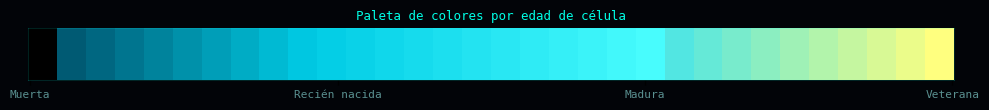

✅ Colormap creado con 32 colores


In [6]:
def crear_colormap():
    """Colormap: negro → cian → blanco → dorado, según edad de la célula."""
    n = 32
    lista = [(0, 0, 0, 1)]  # 0 = muerta: negro

    for i in range(1, n):
        t = i / (n - 1)
        if t < 0.3:
            s = t / 0.3
            r, g, b = 0, 0.3 + 0.5*s, 0.4 + 0.5*s        # cian oscuro
        elif t < 0.7:
            s = (t - 0.3) / 0.4
            r, g, b = s*0.3, 0.8 + 0.2*s, 0.9 + 0.1*s    # cian brillante
        else:
            s = (t - 0.7) / 0.3
            r, g, b = 0.3 + 0.7*s, 0.9 + 0.1*s, 0.9-0.4*s  # dorado
        lista.append((r, g, b, 1.0))

    return colors.ListedColormap(lista)


# Previsualizar la paleta
cmap = crear_colormap()
fig_c, ax_c = plt.subplots(figsize=(10, 1.2), facecolor='#020408')
gradient = np.linspace(0, 31, 256).reshape(1, -1)
ax_c.imshow(gradient, cmap=cmap, aspect='auto', vmin=0, vmax=31)
ax_c.set_xticks([0, 85, 170, 255])
ax_c.set_xticklabels(['Muerta', 'Recién nacida', 'Madura', 'Veterana'],
                      color='#5a9090', fontsize=8, fontfamily='monospace')
ax_c.set_yticks([])
ax_c.set_title('Paleta de colores por edad de célula',
               color='#00ffe5', fontsize=9, fontfamily='monospace')
for sp in ax_c.spines.values():
    sp.set_edgecolor('#00ffe522')
plt.tight_layout()
plt.show()
print("✅ Colormap creado con", cmap.N, "colores")

## 📸 7. Visualización estática — evolución en mosaico

Mostramos la evolución de varias generaciones lado a lado.

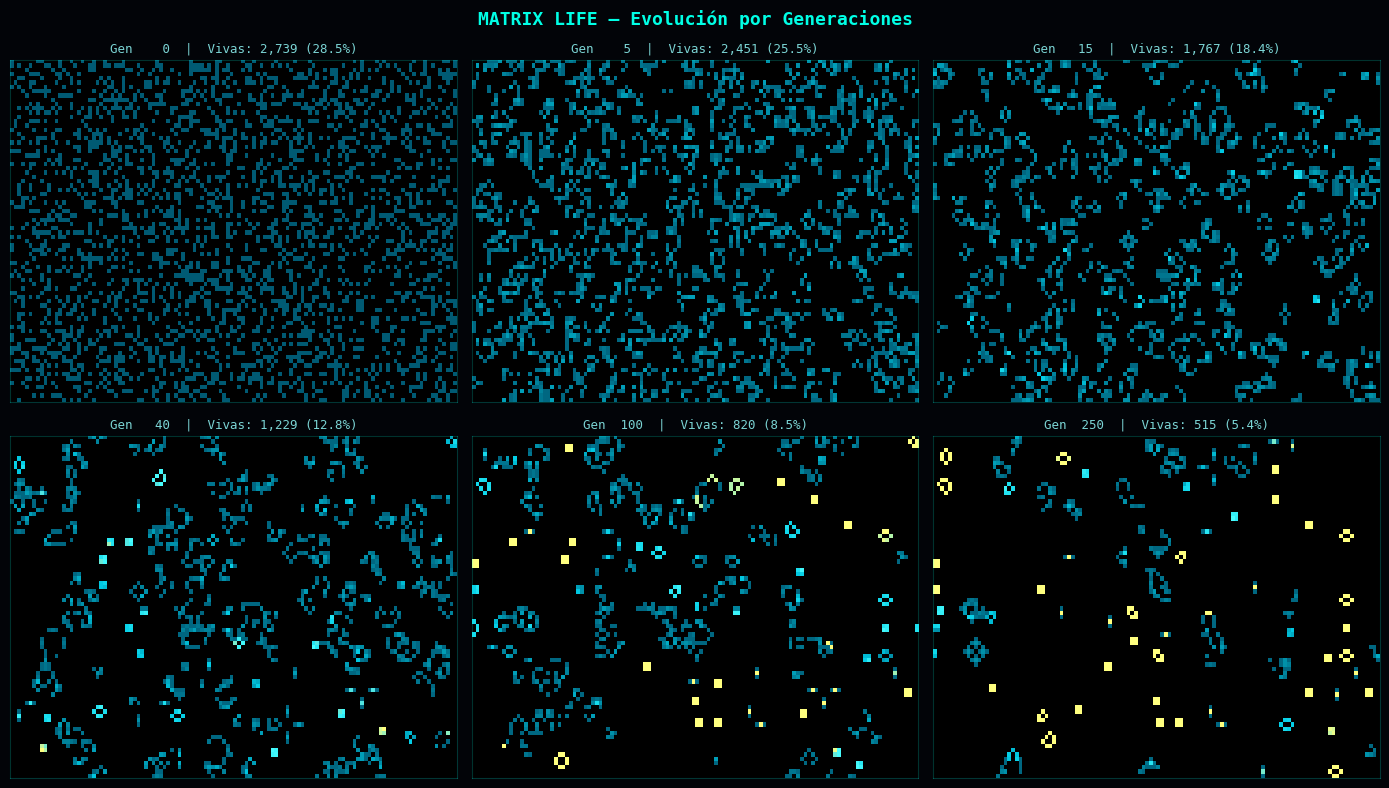

✅ Evolución visualizada: 6 generaciones


In [7]:
def matriz_visual(matriz, edad):
    """Convierte matriz+edad en valores para el colormap (0..31)."""
    return np.where(matriz == 1, np.clip(edad + 1, 1, 31), 0)


# Generar evolución desde estado aleatorio
np.random.seed(7)
m = crear_matriz_aleatoria(FILAS, COLS, DENSI)
e = np.zeros((FILAS, COLS), dtype=np.int8)

generaciones = [0, 5, 15, 40, 100, 250]
snapshots = {}

gen_actual = 0
snapshots[0] = (m.copy(), e.copy())

for g in generaciones[1:]:
    while gen_actual < g:
        m, e = siguiente_generacion(m, e)
        gen_actual += 1
    snapshots[g] = (m.copy(), e.copy())

# Visualizar
fig_s, axes = plt.subplots(2, 3, figsize=(14, 8), facecolor='#020408')
fig_s.suptitle('MATRIX LIFE — Evolución por Generaciones',
               color='#00ffe5', fontsize=13, fontfamily='monospace', fontweight='bold', y=0.98)

for ax, g in zip(axes.flat, generaciones):
    mat, ed = snapshots[g]
    ax.imshow(matriz_visual(mat, ed), cmap=cmap, vmin=0, vmax=31,
              interpolation='nearest', aspect='auto')
    vivas = mat.sum()
    pct = 100 * vivas / (FILAS * COLS)
    ax.set_title(f'Gen {g:>4}  |  Vivas: {vivas:,} ({pct:.1f}%)',
                 color='#7bd4d4', fontsize=9, fontfamily='monospace', pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor('#00ffe533')
        sp.set_linewidth(0.8)
    ax.set_facecolor('#020408')

plt.tight_layout()
plt.show()
print(f"✅ Evolución visualizada: {len(generaciones)} generaciones")

## 📊 8. Análisis estadístico — dinámica de la población

Ejecutamos 500 generaciones y graficamos cómo evoluciona la población.

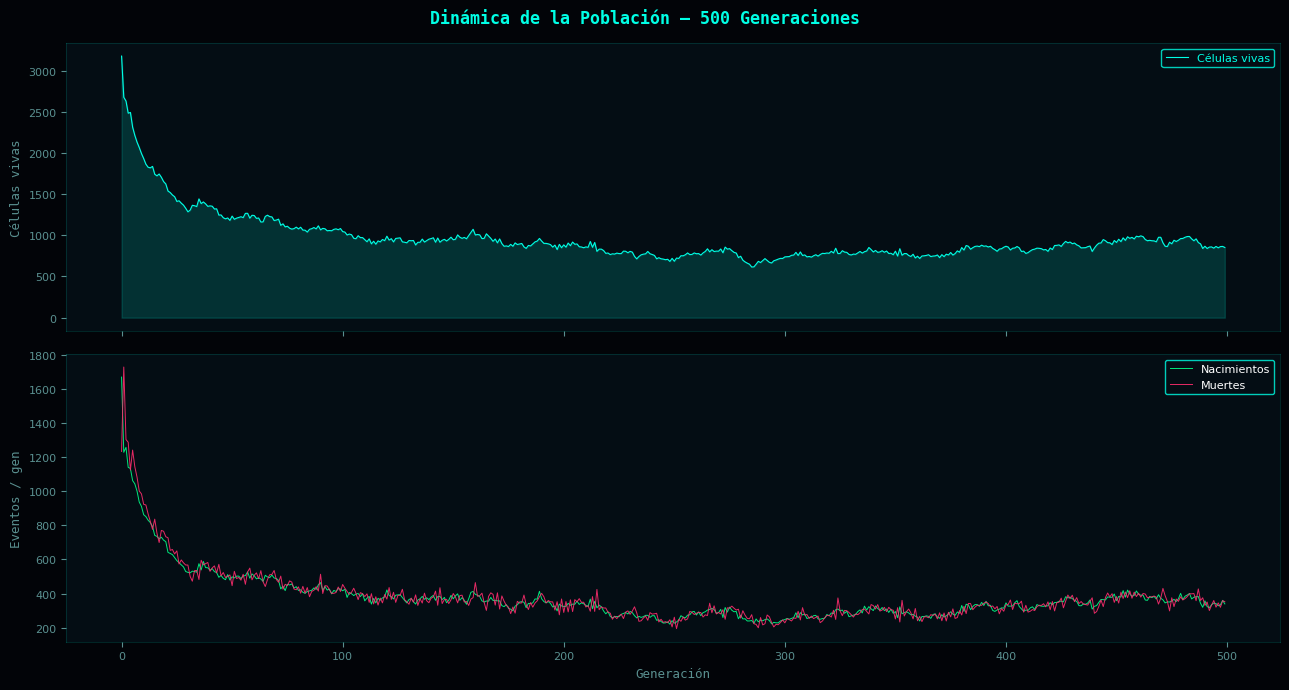

  Máximo de células vivas: 3,175  (gen 0)
  Mínimo de células vivas: 615  (gen 285)
  Promedio de células vivas: 958


In [8]:
# Simular 500 generaciones y registrar estadísticas
np.random.seed(42)
m_stat = crear_matriz_aleatoria(FILAS, COLS, DENSI)
e_stat = np.zeros((FILAS, COLS), dtype=np.int8)

historial = {'gen': [], 'vivas': [], 'nacimientos': [], 'muertes': []}

prev = m_stat.copy()
for g in range(500):
    m_stat, e_stat = siguiente_generacion(m_stat, e_stat)
    nacimientos = int(((prev == 0) & (m_stat == 1)).sum())
    muertes     = int(((prev == 1) & (m_stat == 0)).sum())
    historial['gen'].append(g)
    historial['vivas'].append(int(m_stat.sum()))
    historial['nacimientos'].append(nacimientos)
    historial['muertes'].append(muertes)
    prev = m_stat.copy()

# Graficar
fig_g, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
                                   facecolor='#020408', sharex=True)
fig_g.suptitle('Dinámica de la Población — 500 Generaciones',
               color='#00ffe5', fontsize=12, fontfamily='monospace', fontweight='bold')

gens = historial['gen']

# Población total
ax1.plot(gens, historial['vivas'], color='#00ffe5', linewidth=0.8, label='Células vivas')
ax1.fill_between(gens, historial['vivas'], alpha=0.15, color='#00ffe5')
ax1.set_facecolor('#040d14')
ax1.set_ylabel('Células vivas', color='#5a9090', fontfamily='monospace', fontsize=9)
ax1.tick_params(colors='#5a9090', labelsize=8)
ax1.spines[:].set_edgecolor('#00ffe522')
ax1.legend(loc='upper right', facecolor='#040d14', edgecolor='#00ffe533',
           labelcolor='#00ffe5', fontsize=8)
ax1.yaxis.label.set_fontfamily('monospace')

# Nacimientos vs muertes
ax2.plot(gens, historial['nacimientos'], color='#00ff88', linewidth=0.7,
         label='Nacimientos', alpha=0.9)
ax2.plot(gens, historial['muertes'],     color='#ff2d6e', linewidth=0.7,
         label='Muertes',     alpha=0.9)
ax2.set_facecolor('#040d14')
ax2.set_xlabel('Generación', color='#5a9090', fontfamily='monospace', fontsize=9)
ax2.set_ylabel('Eventos / gen', color='#5a9090', fontfamily='monospace', fontsize=9)
ax2.tick_params(colors='#5a9090', labelsize=8)
ax2.spines[:].set_edgecolor('#00ffe522')
ax2.legend(loc='upper right', facecolor='#040d14', edgecolor='#00ffe533',
           labelcolor='white', fontsize=8)
ax2.xaxis.label.set_fontfamily('monospace')
ax2.yaxis.label.set_fontfamily('monospace')

plt.tight_layout()
plt.show()

max_vivas = max(historial['vivas'])
min_vivas = min(historial['vivas'])
print(f"  Máximo de células vivas: {max_vivas:,}  (gen {historial['vivas'].index(max_vivas)})")
print(f"  Mínimo de células vivas: {min_vivas:,}  (gen {historial['vivas'].index(min_vivas)})")
print(f"  Promedio de células vivas: {sum(historial['vivas'])//len(historial['vivas']):,}")

## 🎬 9. Animación interactiva completa

Esta celda lanza la **ventana interactiva** con todos los controles.

> ⚠️ **Requiere backend interactivo de matplotlib.**  
> Si estás en JupyterLab, ejecuta primero: `%matplotlib widget` (necesitas `ipympl`).  
> Si usas Jupyter Notebook clásico: `%matplotlib notebook`.  
> También puedes abrir directamente el archivo `matrix_life.py` para la versión completa.

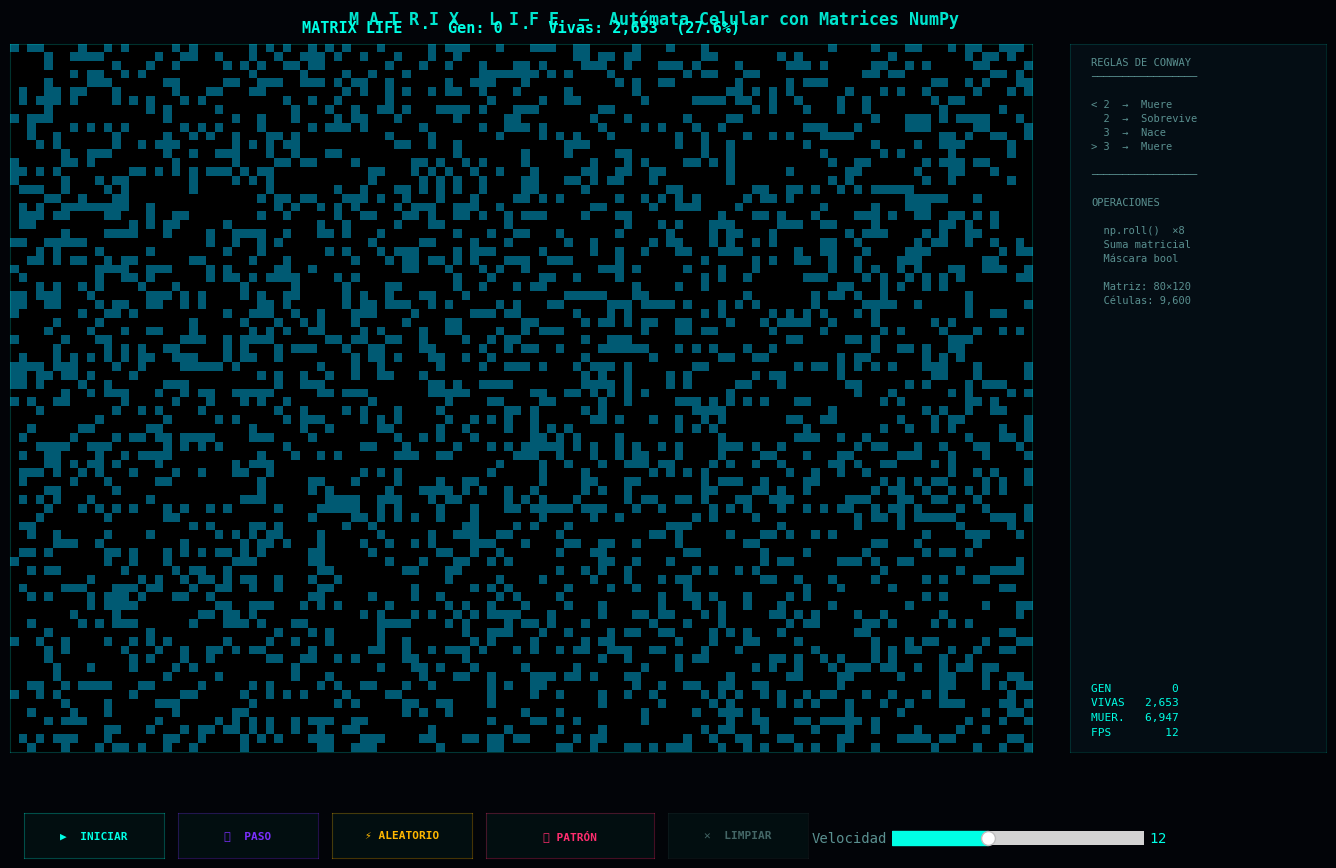

In [9]:
# ── Para animación interactiva en Jupyter, descomenta una de estas líneas: ──
# %matplotlib widget    # JupyterLab con ipympl instalado
# %matplotlib notebook  # Jupyter Notebook clásico

plt.style.use('dark_background')

# ── Estado global ──
estado = {
    'matriz':    crear_matriz_aleatoria(FILAS, COLS, DENSI),
    'edad':      np.zeros((FILAS, COLS), dtype=np.int8),
    'gen':       0,
    'corriendo': False,
    'velocidad': FPS,
}

# ── Figura ──
fig = plt.figure(figsize=(14, 9), facecolor='#020408')
fig.canvas.manager.set_window_title('MATRIX LIFE — Autómata Celular')

gs = fig.add_gridspec(2, 2, width_ratios=[4,1], height_ratios=[10,1],
                      left=0.04, right=0.98, top=0.93, bottom=0.03,
                      hspace=0.08, wspace=0.06)

ax_main = fig.add_subplot(gs[0, 0])
ax_info = fig.add_subplot(gs[0, 1])

ax_main.set_facecolor('#020408')
ax_main.set_xticks([]); ax_main.set_yticks([])
for sp in ax_main.spines.values():
    sp.set_edgecolor('#00ffe533'); sp.set_linewidth(0.8)

im = ax_main.imshow(
    matriz_visual(estado['matriz'], estado['edad']),
    cmap=cmap, vmin=0, vmax=31, interpolation='nearest', aspect='auto'
)
titulo = ax_main.set_title('MATRIX LIFE  ·  Gen: 0  ·  Vivas: 0',
    color='#00ffe5', fontsize=11, fontfamily='monospace', fontweight='bold', pad=8)

ax_info.set_facecolor('#040d14')
ax_info.set_xticks([]); ax_info.set_yticks([])
for sp in ax_info.spines.values():
    sp.set_edgecolor('#00ffe522')

ax_info.text(0.08, 0.98,
    "REGLAS DE CONWAY\n─────────────────\n\n"
    "< 2  →  Muere\n  2  →  Sobrevive\n  3  →  Nace\n> 3  →  Muere\n\n"
    "─────────────────\n\nOPERACIONES\n\n"
    "  np.roll()  ×8\n  Suma matricial\n  Máscara bool\n"
    f"\n  Matriz: {FILAS}×{COLS}\n  Células: {FILAS*COLS:,}",
    transform=ax_info.transAxes, va='top', ha='left',
    color='#5a9090', fontsize=7.5, fontfamily='monospace', linespacing=1.5)

txt_stats = ax_info.text(0.08, 0.02, "", transform=ax_info.transAxes,
    va='bottom', ha='left', color='#00ffe5', fontsize=8,
    fontfamily='monospace', linespacing=1.6)

fig.text(0.5, 0.968,
    'M A T R I X   L I F E  —  Autómata Celular con Matrices NumPy',
    ha='center', va='top', color='#00ffe5', fontsize=12,
    fontfamily='monospace', fontweight='bold', alpha=0.9)

# ── Botones y slider ──
from matplotlib.widgets import Button, Slider

ax_play  = fig.add_axes([0.05, 0.025, 0.10, 0.05])
ax_step  = fig.add_axes([0.16, 0.025, 0.10, 0.05])
ax_rand  = fig.add_axes([0.27, 0.025, 0.10, 0.05])
ax_pat   = fig.add_axes([0.38, 0.025, 0.12, 0.05])
ax_clear = fig.add_axes([0.51, 0.025, 0.10, 0.05])
ax_spd   = fig.add_axes([0.67, 0.032, 0.18, 0.03])

def make_btn(ax, label, ct='#00ffe5', ec='#00ffe544'):
    ax.set_facecolor('#020e10')
    for sp in ax.spines.values(): sp.set_edgecolor(ec); sp.set_linewidth(0.8)
    btn = Button(ax, label, color='#020e10', hovercolor='#041a1a')
    btn.label.set_color(ct); btn.label.set_fontfamily('monospace')
    btn.label.set_fontsize(8); btn.label.set_fontweight('bold')
    return btn

btn_play  = make_btn(ax_play,  '▶  INICIAR',   '#00ffe5', '#00ffe544')
btn_step  = make_btn(ax_step,  '⏭  PASO',      '#7b2fff', '#7b2fff44')
btn_rand  = make_btn(ax_rand,  '⚡ ALEATORIO',  '#ffb800', '#ffb80044')
btn_pat   = make_btn(ax_pat,   '🛸 PATRÓN',    '#ff2d6e', '#ff2d6e44')
btn_clear = make_btn(ax_clear, '✕  LIMPIAR',   '#446666', '#22333344')
slider_vel = Slider(ax_spd, 'Velocidad', 1, 30, valinit=FPS, valstep=1, color='#00ffe5')
slider_vel.label.set_color('#5a9090'); slider_vel.label.set_fontfamily('monospace')
slider_vel.valtext.set_color('#00ffe5'); slider_vel.valtext.set_fontfamily('monospace')

_idx = [0]

def avanzar():
    estado['matriz'], estado['edad'] = siguiente_generacion(estado['matriz'], estado['edad'])
    estado['gen'] += 1

def actualizar():
    im.set_data(matriz_visual(estado['matriz'], estado['edad']))
    v = int(estado['matriz'].sum())
    g = estado['gen']
    titulo.set_text(f'MATRIX LIFE  ·  Gen: {g:,}  ·  Vivas: {v:,}  ({100*v/(FILAS*COLS):.1f}%)')
    txt_stats.set_text(f"GEN    {g:>6,}\nVIVAS  {v:>6,}\nMUER.  {FILAS*COLS-v:>6,}\nFPS    {estado['velocidad']:>6}")

def cb_play(e):
    estado['corriendo'] = not estado['corriendo']
    btn_play.label.set_text('⏸  PAUSAR' if estado['corriendo'] else '▶  INICIAR')
    fig.canvas.draw_idle()

def cb_step(e):
    estado['corriendo'] = False; btn_play.label.set_text('▶  INICIAR')
    avanzar(); actualizar(); fig.canvas.draw_idle()

def cb_random(e):
    estado['matriz'] = crear_matriz_aleatoria(FILAS, COLS, DENSI)
    estado['edad']   = np.zeros((FILAS, COLS), dtype=np.int8)
    estado['gen']    = 0; actualizar(); fig.canvas.draw_idle()

def cb_patron(e):
    estado['matriz'] = insertar_patron(estado['matriz'], _idx[0])
    btn_pat.label.set_text(f"🛸 {list(PATRONES.keys())[_idx[0]%len(PATRONES)][:8]}")
    _idx[0] += 1; actualizar(); fig.canvas.draw_idle()

def cb_clear(e):
    estado['corriendo'] = False; btn_play.label.set_text('▶  INICIAR')
    estado['matriz'] = np.zeros((FILAS, COLS), dtype=np.int8)
    estado['edad']   = np.zeros((FILAS, COLS), dtype=np.int8)
    estado['gen']    = 0; actualizar(); fig.canvas.draw_idle()

btn_play.on_clicked(cb_play); btn_step.on_clicked(cb_step)
btn_rand.on_clicked(cb_random); btn_pat.on_clicked(cb_patron)
btn_clear.on_clicked(cb_clear)
slider_vel.on_changed(lambda v: estado.update({'velocidad': int(v)}))

def animate(frame):
    if estado['corriendo']:
        avanzar(); actualizar()
    return [im, titulo, txt_stats]

ani = animation.FuncAnimation(fig, animate,
    interval=max(33, 1000//FPS), blit=False, cache_frame_data=False)

def tick(_):
    ani.event_source.interval = max(25, 1000 // estado['velocidad'])
fig.canvas.mpl_connect('draw_event', tick)

actualizar()
plt.show()

---

## 📝 Resumen — ¿Qué aprendimos?

| Concepto | Aplicación en este notebook |
|:---|:---|
| **Matrices 2D** | El mundo del autómata es `np.ndarray` de forma `(FILAS, COLS)` |
| **`np.roll()`** | Desplaza la matriz para contar vecinos sin bucles |
| **Máscaras booleanas** | Aplican las reglas de Conway en paralelo sobre toda la matriz |
| **Broadcasting** | Operaciones elemento a elemento sin bucles explícitos |
| **`np.where()`** | Actualiza edades con lógica condicional vectorizada |
| **Matplotlib** | Visualización con `imshow`, `FuncAnimation`, `Button`, `Slider` |
| **Colormaps** | Paleta personalizada que codifica la edad de cada célula |

### Complejidad temporal
- Sin vectorización: **O(FILAS × COLS)** iteraciones Python por generación
- Con `np.roll()` + álgebra matricial: **1 operación NumPy** por dirección (8 en total) — el bucle ocurre en C, no en Python

> *"El Juego de la Vida demuestra cómo reglas simples aplicadas sobre una matriz pueden generar una complejidad ilimitada."* — John Conway
